<a href="https://colab.research.google.com/github/AssiaAb/COLAB/blob/main/Algiers_Weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


In [ ]:
import pandas as pd

# تحميل الملف (بدل المسار بالمسار الصحيح عندك)
df = pd.read_csv("/Algiers_Weather_Data.csv.csv")

# عرض أول 5 أسطر
print(df.head())


         time  weathercode (wmo code)  temperature_2m_max (°C)  \
0  2002-01-01                       3                     15.4   
1  2002-01-02                      51                     16.2   
2  2002-01-03                      51                     17.2   
3  2002-01-04                      61                     13.6   
4  2002-01-05                      51                     13.8   

   temperature_2m_min (°C)  temperature_2m_mean (°C)  \
0                     10.5                      12.2   
1                      9.8                      12.2   
2                      8.4                      12.0   
3                      7.8                      10.2   
4                      7.9                      10.6   

   apparent_temperature_max (°C)  apparent_temperature_min (°C)  \
0                           11.9                            7.5   
1                           14.1                            6.7   
2                           15.1                            5.2  

In [ ]:
# عرض أسماء الأعمدة
print(df.columns)

# عرض معلومات سريعة على البيانات
print(df.info())


Index(['time', 'weathercode (wmo code)', 'temperature_2m_max (°C)',
       'temperature_2m_min (°C)', 'temperature_2m_mean (°C)',
       'apparent_temperature_max (°C)', 'apparent_temperature_min (°C)',
       'apparent_temperature_mean (°C)', 'sunrise (iso8601)',
       'sunset (iso8601)', 'precipitation_sum (mm)', 'rain_sum (mm)',
       'snowfall_sum (cm)', 'precipitation_hours (h)',
       'windspeed_10m_max (km/h)', 'windgusts_10m_max (km/h)',
       'winddirection_10m_dominant (°)', 'shortwave_radiation_sum (MJ/m²)',
       'et0_fao_evapotranspiration (mm)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7913 entries, 0 to 7912
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   time                             7913 non-null   object 
 1   weathercode (wmo code)           7913 non-null   int64  
 2   temperature_2m_max (°C)          7913 non-null

In [ ]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Change this path to the correct location in your Drive
file_path = '/content/drive/MyDrive/Algiers_Weather_Data.csv.csv'

# Now read the CSV using the updated file_path
df = pd.read_csv(file_path)

# Proceed with the rest of your code
df['time'] = pd.to_datetime(df['time'])
df['year'] = df['time'].dt.year
avg_temp_by_year = df.groupby('year')['temperature_2m_mean (°C)'].mean()
print(avg_temp_by_year)

year
2002    17.641096
2003    17.986575
2004    17.276230
2005    16.798904
2006    18.125479
2007    17.290411
2008    17.254918
2009    17.658630
2010    17.379178
2011    17.745479
2012    17.684426
2013    17.163562
2014    18.146575
2015    17.949041
2016    18.118852
2017    18.260548
2018    17.643014
2019    18.134521
2020    18.561749
2021    18.606027
2022    19.072329
2023    18.865844
Name: temperature_2m_mean (°C), dtype: float64


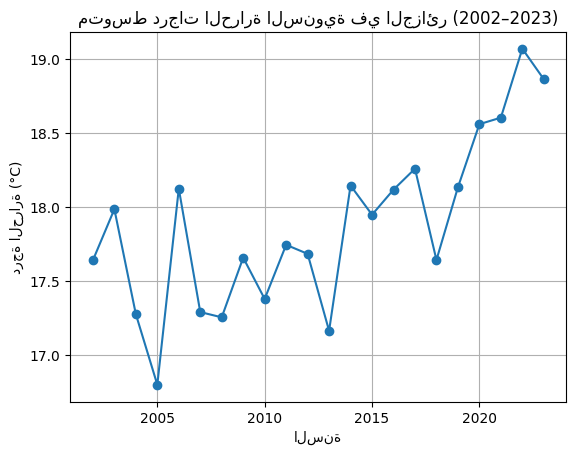

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# تحميل البيانات
df = pd.read_csv("/Algiers_Weather_Data.csv.csv")

# تحويل عمود الوقت إلى نوع تاريخ
df['time'] = pd.to_datetime(df['time'])

# استخراج السنة
df['year'] = df['time'].dt.year

# حساب المعدل السنوي لدرجة الحرارة المتوسطة
avg_temp_by_year = df.groupby('year')['temperature_2m_mean (°C)'].mean()

# عرض النتائج
print(avg_temp_by_year)

# رسم بياني
avg_temp_by_year.plot(kind='line', marker='o', title='متوسط درجات الحرارة السنوية في الجزائر (2002–2023)')
plt.ylabel("درجة الحرارة (°C)")
plt.xlabel("السنة")
plt.grid(True)
plt.show()


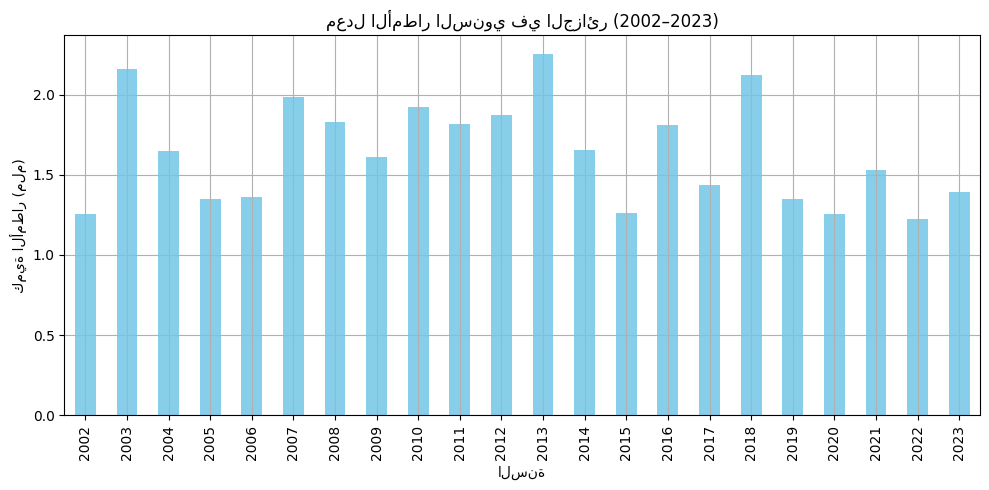

In [ ]:
# تحليل الأمطار
avg_rain_by_year = df.groupby('year')['precipitation_sum (mm)'].mean()

# رسم بياني للأمطار
avg_rain_by_year.plot(kind='bar', color='skyblue', title='معدل الأمطار السنوي في الجزائر (2002–2023)', figsize=(10,5))
plt.xlabel("السنة")
plt.ylabel("كمية الأمطار (ملم)")
plt.grid(True)
plt.tight_layout()
plt.show()


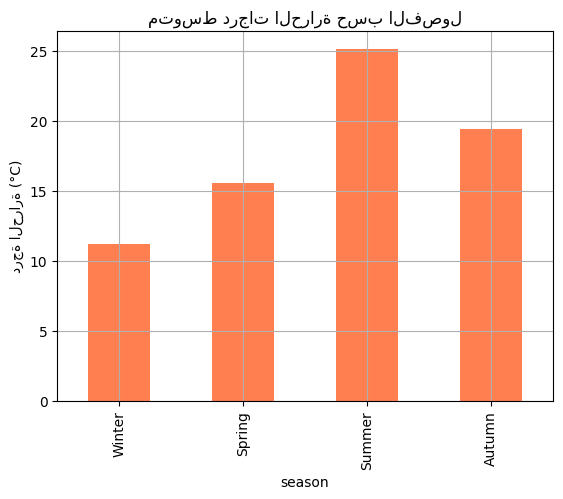

In [ ]:
# استخراج الشهر من التاريخ
df['month'] = df['time'].dt.month

# إنشاء عمود الفصول
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['month'].apply(get_season)

# تحليل الحرارة حسب الفصول
avg_temp_by_season = df.groupby('season')['temperature_2m_mean (°C)'].mean()
avg_temp_by_season = avg_temp_by_season[['Winter', 'Spring', 'Summer', 'Autumn']]  # ترتيب يدوي

# رسم بياني
avg_temp_by_season.plot(kind='bar', color='coral', title='متوسط درجات الحرارة حسب الفصول')
plt.ylabel("درجة الحرارة (°C)")
plt.grid(True)
plt.show()


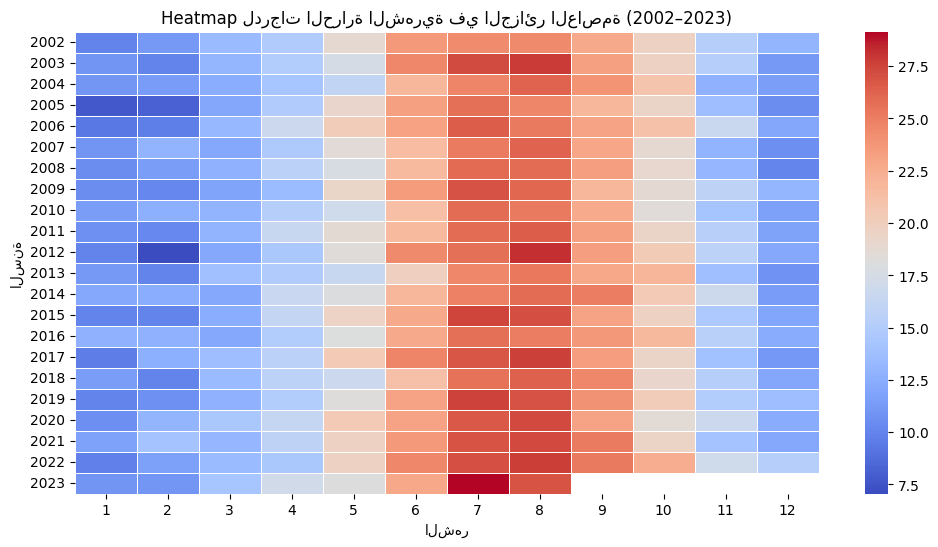

In [ ]:
import seaborn as sns
import numpy as np

# استخراج الشهر والسنة
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month

# حساب متوسط الحرارة حسب السنة والشهر
monthly_avg = df.groupby(['year', 'month'])['temperature_2m_mean (°C)'].mean().unstack()

# رسم Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(monthly_avg, cmap="coolwarm", annot=False, linewidths=.5, fmt=".1f")
plt.title("Heatmap لدرجات الحرارة الشهرية في الجزائر العاصمة (2002–2023)")
plt.xlabel("الشهر")
plt.ylabel("السنة")
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')